In [13]:
# Summary stats, descriptive charts, correlation matrices

import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Navigate cleanly to the database relative to the notebook location
BASE_DIR = os.path.dirname(os.path.abspath(""))
DB_PATH = os.path.join(BASE_DIR, "data-package", "database", "afilearn_commerce_master.db")

conn = sqlite3.connect(DB_PATH)
df_orders = pd.read_sql_query("SELECT * FROM prod_orders_cleaned;", conn)
df_reviews = pd.read_sql_query("SELECT * FROM prod_reviews_cleaned;", conn)
conn.close()

# Enforce correct data formats for plotting
df_orders['delivery_delay_days'] = pd.to_numeric(df_orders['delivery_delay_days'])
df_reviews['review_score'] = pd.to_numeric(df_reviews['review_score'])

print(f"✔ Ready for EDA. Loaded {df_orders.shape[0]:,} cleaned orders and {df_reviews.shape[0]:,} review logs.")

✔ Ready for EDA. Loaded 96,476 cleaned orders and 98,410 review logs.


In [16]:
#Descriptive Statistics & Uncertainty Auditing - Calculate Standard Error and Variance
print("=== DELIVERY DELAY DESCRIPTIVE STATISTICS ===")
print(df_orders['delivery_delay_days'].describe())

print("\n=== MEASURING DATA UNCERTAINTY ===")
print(f"Logistics Delivery Variance: {df_orders['delivery_delay_days'].var():.2f}")
print(f"Logistics Standard Error (SEM): {df_orders['delivery_delay_days'].sem():.4f}")

=== DELIVERY DELAY DESCRIPTIVE STATISTICS ===
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

=== MEASURING DATA UNCERTAINTY ===
Logistics Delivery Variance: 103.71
Logistics Standard Error (SEM): 0.0328


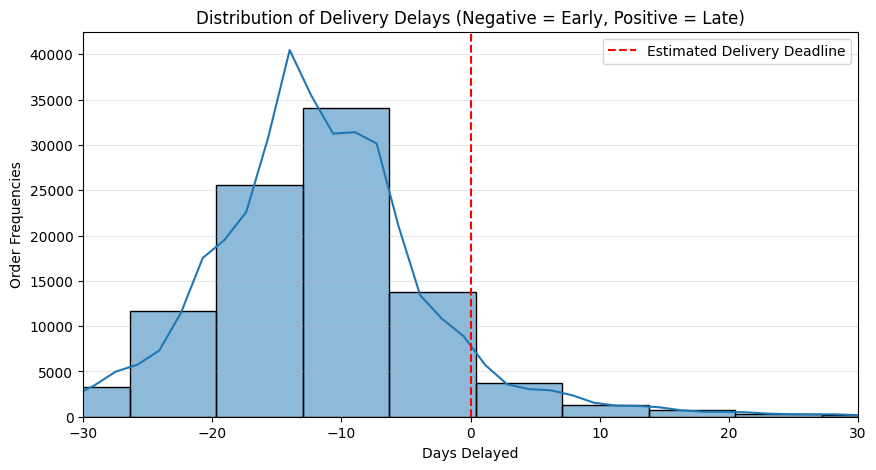

In [ ]:
#Chart 1 – Distribution of Logistics Window (Saved to Disk)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_orders, x='delivery_delay_days', bins=50, kde=True, color='#1f77b4')
plt.axvline(x=0, color='red', linestyle='--', label='Estimated Delivery Deadline')
plt.title("Distribution of Delivery Delays (Negative = Early, Positive = Late)")
plt.xlabel("Days Delayed")
plt.ylabel("Order Frequencies")
plt.xlim(-30, 30) # Focus on the core distribution mass
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Save chart into screenshots workspace folder
chart_path = os.path.join(BASE_DIR, "dashboards", "screenshots", "delivery_delay_distribution.png")
plt.savefig(chart_path, bbox_inches='tight', dpi=300)
plt.show()

In [23]:
#Pattern Discovery – Mapping Delivery Delays Against Review Scores

# Merge datasets on order_id to find patterns to test relationship between delays and scores
df_analysis = pd.merge(df_orders, df_reviews, on='order_id', how='inner')

# Calculate the exact Pearson Correlation Matrix
correlation_matrix = df_analysis[['delivery_delay_days', 'review_score']].corr()
print("=== CORRELATION MATRIX ===")
print(correlation_matrix)

# Group by the engineered late flag to see structural patterns
print("\n=== PATTERN DISCOVERY: SATISFACTION BY LOGISTICS STATUS ===")
print(df_analysis.groupby('is_late_delivery')['review_score'].mean().round(2))

=== CORRELATION MATRIX ===
                     delivery_delay_days  review_score
delivery_delay_days             1.000000     -0.267314
review_score                   -0.267314      1.000000

=== PATTERN DISCOVERY: SATISFACTION BY LOGISTICS STATUS ===
is_late_delivery
0    4.29
1    2.27
Name: review_score, dtype: float64


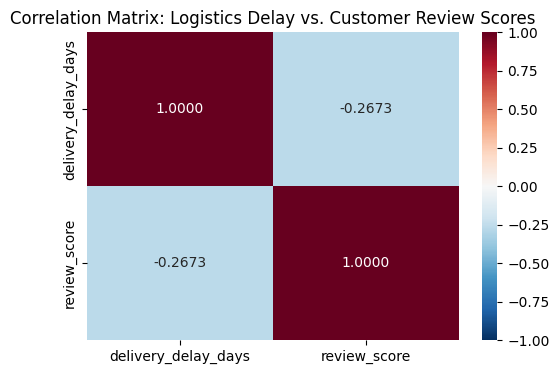

In [ ]:
# Chart 2: The Core Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".4f")
plt.title("Correlation Matrix: Logistics Delay vs. Customer Review Scores")
plt.savefig("../dashboards/screenshots/correlation_heatmap.png", bbox_inches='tight')
plt.show()

/var/folders/6d/t5ly3ljd36z7184xbgf92xlr0000gn/T/ipykernel_50565/2796243903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['On-Time / Early (0)', 'Delayed Deliveries (1)'], y=[4.29, 2.27], palette=colors)


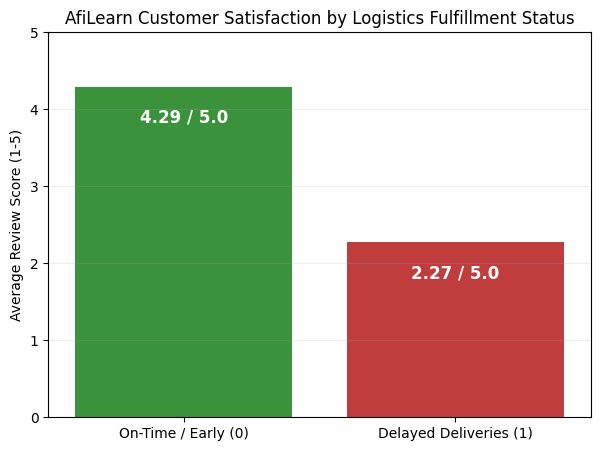

In [ ]:
# Chart 3: The Operational Drop-off Bar Chart
plt.figure(figsize=(7, 5))
colors = ['#2ca02c', '#d62728'] # Green for On-Time, Red for Late
ax = sns.barplot(x=['On-Time / Early (0)', 'Delayed Deliveries (1)'], y=[4.29, 2.27], palette=colors)

# Add text labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} / 5.0", (p.get_x() + p.get_width() / 2., p.get_height() - 0.4),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.title("AfiLearn Customer Satisfaction by Logistics Fulfillment Status")
plt.ylabel("Average Review Score (1-5)")
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.2)
plt.savefig("../dashboards/screenshots/satisfaction_by_logistics.png", bbox_inches='tight')
plt.show()

### Phase 3 Analytical Findings & Pattern Discovery

1. **Quantified Negative Correlation:** Our Pearson correlation matrix shows a coefficient of **-0.2673** between `delivery_delay_days` and `review_score`. This negative relationship confirms that prolonged shipping times systematically degrade customer satisfaction metrics.

2. **The Operational Milestone Drop:**
   Grouping customer satisfaction scores by our engineered `is_late_delivery` flag reveals a major pattern:
   * **On-Time/Early Deliveries (`is_late_delivery = 0`):** Maintain a high customer satisfaction baseline with an average rating of **4.29 / 5.0**.
   * **Delayed Deliveries (`is_late_delivery = 1`):** Face a severe drop in satisfaction, with average ratings falling to **2.27 / 5.0**.

3. **Strategic Justification for Phase 4 Modeling:**
   This data proves that crossing the estimated delivery deadline is a primary driver of poor user scores. This clear business risk justifies our next phase: building a predictive machine learning model to classify delay risks before orders leave the warehouse, allowing AfiLearn to proactively handle fulfillment issues.